# NinaPro DB1 — Learned Dynamic GAT–TCN–LSTM (Final Direct-Fusion Version)

This notebook implements a **learned dynamic electrode graph** for continuous wrist-angle regression.

## Why this version

Previous experiments showed:

- **TCN–LSTM baseline:** strong temporal model.
- **Cosine / muscle-synergy graph:** improved \(R^2\), but RMSE remained slightly worse than the baseline.
- **Spatio-temporal graph:** added complexity but did not improve the final result.

This notebook therefore returns to the strongest direct-fusion idea, but removes the hand-designed graph.

## Proposed model

```text
10-channel sEMG
      │
      ├── MAV/RMS ─────────→ TCN ───────────────┐
      │                                         │
      └── 14-D node features                    │
             ↓                                  │
       learned dynamic                          │
       electrode graph                          │
             ↓                                  │
       dynamic GAT × 2                          │
             ↓                                  │
       graph feature (32-D)                     │
             ↓                                  │
       gated residual fusion ───────────────────┤
                                                ↓
                                              LSTM
                                                ↓
                                      continuous wrist angle
```

### Graph

- **Nodes:** 10 sEMG electrodes.
- **Node features:** 10 raw samples + MAV + RMS + waveform length + variance = 14.
- **Edges:** fully learned for every 100-ms frame.
- **No cosine similarity.**
- **No top-k pruning.**
- **No fixed spatial graph.**
- A learnable global electrode bias is combined with an input-dependent dynamic adjacency.

### Repetition protocol

Development:
- train = repetitions **1–4**
- validation = repetition **5**

Final:
- train = repetitions **1–5**
- test = repetitions **6–10**

The test set is used only after validation has selected the training schedule.

### Training stages

1. Train the internal TCN–LSTM warm-start.
2. Freeze the TCN–LSTM weights and train only the graph + gated fusion.
3. Unfreeze everything and fine-tune gently with much smaller backbone learning rates.

The hybrid is initialized to reproduce the TCN–LSTM prediction exactly.

## 1. Imports and reproducibility

In [27]:
import gc
import math
import os
import random
import shutil
import time
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.io import loadmat
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import weight_norm
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42

def reset_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_seed()

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.10.0+cu128
Device: cuda


## 2. Configuration

In [28]:
FS = 100
EXERCISE = 2
SUBJECTS = tuple(range(1, 9))
N_EMG = 10
N_GLOVE = 22

OFFICIAL_URL_TEMPLATE = (
    "https://ninapro.hevs.ch/files/DB1/Preprocessed/s{subject}.zip"
)

MOVEMENTS = {
    13: "WF",
    16: "WUD",
    17: "WECH",
}

TARGET_GLOVE_COLUMN = 20

# Repetition-wise protocol
DEV_TRAIN_REPETITIONS = (1, 2, 3, 4)
VAL_REPETITIONS = (5,)
FINAL_TRAIN_REPETITIONS = (1, 2, 3, 4, 5)
TEST_REPETITIONS = (6, 7, 8, 9, 10)

# Same preprocessing family as the previous experiments
WINDOW_SAMPLES = 10
OVERLAP_SAMPLES = 1
WINDOW_STEP = WINDOW_SAMPLES - OVERLAP_SAMPLES
SEQUENCE_LENGTH = 20
SEQUENCE_STRIDE = 1
TARGET_AHEAD_SAMPLES = 1
PRE_MOVEMENT_REST_SAMPLES = 300

BASE_FEATURES = 20
NODE_STATS = 4
NODE_FEATURES = WINDOW_SAMPLES + NODE_STATS  # 14

# Original TCN-LSTM backbone
TCN_CHANNELS = 25
TCN_KERNEL_SIZE = 15
TCN_DILATIONS = (1, 2, 4)
TEMPORAL_DROPOUT = 0.20
LSTM_HIDDEN_UNITS = 50
LSTM_LAYERS = 5

BACKBONE_EPOCHS = 50
BACKBONE_LR = 0.01
BACKBONE_LR_STEP = 10
BACKBONE_LR_GAMMA = 0.5

# Learned dynamic graph
ELECTRODE_EMBED_DIM = 8
GRAPH_HIDDEN = 32
GRAPH_HEADS = 4
GRAPH_FRAME_DIM = 32
GRAPH_DROPOUT = 0.10
GRAPH_GLOBAL_BIAS_SCALE = 0.10

# Stage 2: graph + fusion only
MAX_ADAPTER_EPOCHS = 35
ADAPTER_PATIENCE = 8
GRAPH_LR = 5e-4
FUSION_LR = 3e-4

# Stage 3: gentle end-to-end fine tuning
MAX_FINETUNE_EPOCHS = 30
FINETUNE_PATIENCE = 8
FINETUNE_GRAPH_LR = 2e-4
FINETUNE_FUSION_LR = 1e-4
FINETUNE_LSTM_LR = 2e-5
FINETUNE_TCN_LR = 1e-5

WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
MIN_VAL_IMPROVEMENT = 1e-5

BATCH_SIZE = 32
NUM_WORKERS = 0

MODEL_NAME = "Learned_Dynamic_GAT_TCN_LSTM"
FORCE_RETRAIN = False

RUN_PRESET = "full"  # "quick" or "full"

if RUN_PRESET == "quick":
    RUN_SUBJECTS = (1,)
    RUN_MOVEMENTS = {17: "WECH"}
    RUN_BACKBONE_EPOCHS = 3
    RUN_MAX_ADAPTER_EPOCHS = 3
    RUN_MAX_FINETUNE_EPOCHS = 3
else:
    RUN_SUBJECTS = SUBJECTS
    RUN_MOVEMENTS = MOVEMENTS
    RUN_BACKBONE_EPOCHS = BACKBONE_EPOCHS
    RUN_MAX_ADAPTER_EPOCHS = MAX_ADAPTER_EPOCHS
    RUN_MAX_FINETUNE_EPOCHS = MAX_FINETUNE_EPOCHS

ON_KAGGLE = Path("/kaggle").exists()

WORK_DIR = (
    Path("/kaggle/working/ninapro_db1_learned_dynamic_gat")
    if ON_KAGGLE
    else Path("./ninapro_db1_learned_dynamic_gat")
)

ZIP_DIR = WORK_DIR / "official_zips"
MAT_DIR = WORK_DIR / "mat_files"
CACHE_DIR = WORK_DIR / "raw_cache"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
RESULT_DIR = WORK_DIR / "results"
FIGURE_DIR = RESULT_DIR / "figures"

for directory in [
    WORK_DIR,
    ZIP_DIR,
    MAT_DIR,
    CACHE_DIR,
    CHECKPOINT_DIR,
    RESULT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Development:", DEV_TRAIN_REPETITIONS, "-> val", VAL_REPETITIONS)
print("Final train:", FINAL_TRAIN_REPETITIONS)
print("Final test:", TEST_REPETITIONS)

Model: Learned_Dynamic_GAT_TCN_LSTM
Development: (1, 2, 3, 4) -> val (5,)
Final train: (1, 2, 3, 4, 5)
Final test: (6, 7, 8, 9, 10)


## 3. Download official NinaPro DB1

In [29]:
def valid_zip(path):
    if not path.exists() or path.stat().st_size == 0:
        return False

    try:
        if not zipfile.is_zipfile(path):
            return False

        with zipfile.ZipFile(path, "r") as archive:
            return archive.testzip() is None

    except Exception:
        return False


def download_subject(subject):
    url = OFFICIAL_URL_TEMPLATE.format(subject=subject)
    zip_path = ZIP_DIR / f"s{subject}.zip"
    partial_path = ZIP_DIR / f"s{subject}.zip.part"

    if valid_zip(zip_path):
        return zip_path

    headers = {"User-Agent": "Mozilla/5.0 NinaPro-DynamicGAT"}
    existing = partial_path.stat().st_size if partial_path.exists() else 0

    if existing:
        headers["Range"] = f"bytes={existing}-"

    response = requests.get(
        url,
        stream=True,
        timeout=(30, 180),
        headers=headers,
    )

    if response.status_code not in (200, 206):
        raise RuntimeError(f"HTTP {response.status_code}: {url}")

    if existing and response.status_code == 200:
        existing = 0
        partial_path.unlink(missing_ok=True)

    total = (
        existing + int(response.headers.get("content-length", 0))
        if response.headers.get("content-length")
        else None
    )

    with open(partial_path, "ab" if existing else "wb") as file, tqdm(
        total=total,
        initial=existing,
        unit="B",
        unit_scale=True,
        desc=f"Subject {subject}",
    ) as progress:
        for chunk in response.iter_content(1024 * 1024):
            if chunk:
                file.write(chunk)
                progress.update(len(chunk))

    partial_path.replace(zip_path)

    if not valid_zip(zip_path):
        raise RuntimeError(f"ZIP validation failed for subject {subject}")

    return zip_path


def extract_subject(subject, zip_path):
    subject_dir = MAT_DIR / f"s{subject:02d}"
    marker = subject_dir / ".complete"

    if marker.exists() and list(subject_dir.rglob("*.mat")):
        return subject_dir

    if subject_dir.exists():
        shutil.rmtree(subject_dir)

    subject_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(subject_dir)

    marker.write_text("ok")
    return subject_dir


for subject in RUN_SUBJECTS:
    folder = extract_subject(subject, download_subject(subject))
    print(
        f"Subject {subject}:",
        len(list(folder.rglob("*.mat"))),
        "MAT files",
    )

Subject 1:   0%|          | 0.00/20.7M [00:00<?, ?B/s]

Subject 1: 3 MAT files


Subject 2:   0%|          | 0.00/25.8M [00:00<?, ?B/s]

Subject 2: 3 MAT files


Subject 3:   0%|          | 0.00/23.1M [00:00<?, ?B/s]

...

Subject 6: 3 MAT files


Subject 7:   0%|          | 0.00/24.1M [00:00<?, ?B/s]

Subject 7: 3 MAT files


Subject 8:   0%|          | 0.00/20.2M [00:00<?, ?B/s]

Subject 8: 3 MAT files


## 4. MATLAB loading and trial extraction

In [30]:
def orient_matrix(array, columns, name):
    array = np.asarray(array).squeeze()

    if array.ndim != 2:
        raise ValueError(f"{name} must be 2-D")

    if array.shape[1] == columns:
        return array

    if array.shape[0] == columns:
        return array.T

    raise ValueError(f"{name} shape {array.shape}")


def load_hdf5_mat(path):
    output = {}

    with h5py.File(path, "r") as file:
        for key in file.keys():
            value = np.array(file[key])
            output[key.lower()] = value.T if value.ndim == 2 else value

    return output


def load_mat(path):
    try:
        raw = loadmat(
            path,
            squeeze_me=True,
            struct_as_record=False,
        )

        return {
            key.lower(): value
            for key, value in raw.items()
            if not key.startswith("__")
        }

    except NotImplementedError:
        return load_hdf5_mat(path)


def scalar_int(value):
    return int(np.asarray(value).squeeze().item())


def find_exercise_file(subject):
    matches = []

    for path in sorted((MAT_DIR / f"s{subject:02d}").rglob("*.mat")):
        try:
            record = load_mat(path)

            if (
                "exercise" in record
                and scalar_int(record["exercise"]) == EXERCISE
            ):
                matches.append(path)

        except Exception:
            pass

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one Exercise-2 file for S{subject}, got {matches}"
        )

    return matches[0]


def load_exercise2(subject):
    path = find_exercise_file(subject)
    record = load_mat(path)

    return {
        "subject": subject,
        "emg": orient_matrix(
            record["emg"],
            N_EMG,
            "emg",
        ).astype(np.float32),
        "glove": orient_matrix(
            record["glove"],
            N_GLOVE,
            "glove",
        ).astype(np.float32),
        "restimulus": np.asarray(
            record["restimulus"]
        ).reshape(-1).astype(np.int16),
        "rerepetition": np.asarray(
            record["rerepetition"]
        ).reshape(-1).astype(np.int16),
    }


@dataclass
class MovementTrial:
    subject: int
    movement: int
    repetition: int
    start: int
    movement_start: int
    end: int


def contiguous_segments(mask):
    change = np.diff(
        np.asarray(mask, dtype=np.int8),
        prepend=0,
        append=0,
    )

    return list(
        zip(
            np.flatnonzero(change == 1),
            np.flatnonzero(change == -1),
        )
    )


def find_movement_trials(record, movement):
    trials = []

    for repetition in range(1, 11):
        mask = (
            (record["restimulus"] == movement)
            & (record["rerepetition"] == repetition)
        )

        segments = contiguous_segments(mask)

        if len(segments) != 1:
            raise RuntimeError(
                f'S{record["subject"]} M{movement} R{repetition}: '
                f"expected 1 segment, got {len(segments)}"
            )

        movement_start, movement_end = segments[0]

        begin = max(
            0,
            movement_start - PRE_MOVEMENT_REST_SAMPLES,
        )

        while (
            begin < movement_start
            and record["restimulus"][begin] != 0
        ):
            begin += 1

        trials.append(
            MovementTrial(
                subject=record["subject"],
                movement=movement,
                repetition=repetition,
                start=begin,
                movement_start=movement_start,
                end=movement_end,
            )
        )

    return trials

## 5. Frame-level features

In [31]:
def extract_base_features(window):
    mav = np.mean(np.abs(window), axis=0)

    rms = np.sqrt(
        np.mean(window ** 2, axis=0)
        + 1e-12
    )

    return np.concatenate(
        [mav, rms]
    ).astype(np.float32)


def extract_node_features(window):
    # window: [10 time samples, 10 electrodes]
    raw = window.T  # [10 electrodes, 10 raw samples]

    mav = np.mean(np.abs(window), axis=0)

    rms = np.sqrt(
        np.mean(window ** 2, axis=0)
        + 1e-12
    )

    waveform_length = np.sum(
        np.abs(np.diff(window, axis=0)),
        axis=0,
    )

    variance = np.var(window, axis=0)

    statistics = np.stack(
        [mav, rms, waveform_length, variance],
        axis=-1,
    )

    return np.concatenate(
        [raw, statistics],
        axis=-1,
    ).astype(np.float32)


def build_trial_frames(record, trial):
    base_frames = []
    node_frames = []
    targets = []
    indices = []

    first_end = trial.start + WINDOW_SAMPLES - 1
    last_end = trial.end - 1 - TARGET_AHEAD_SAMPLES

    for window_end in range(
        first_end,
        last_end + 1,
        WINDOW_STEP,
    ):
        window_start = window_end - WINDOW_SAMPLES + 1
        target_index = window_end + TARGET_AHEAD_SAMPLES

        window = record["emg"][
            window_start:
            window_end + 1
        ]

        base_frames.append(
            extract_base_features(window)
        )

        node_frames.append(
            extract_node_features(window)
        )

        targets.append(
            record["glove"][
                target_index,
                TARGET_GLOVE_COLUMN,
            ]
        )

        indices.append(target_index)

    return (
        np.asarray(base_frames, dtype=np.float32),
        np.asarray(node_frames, dtype=np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(indices, dtype=np.int32),
    )


def make_sequences(base, nodes, targets, indices):
    sequence_base = []
    sequence_nodes = []
    sequence_targets = []
    sequence_indices = []

    for start in range(
        0,
        len(base) - SEQUENCE_LENGTH + 1,
        SEQUENCE_STRIDE,
    ):
        end = start + SEQUENCE_LENGTH

        sequence_base.append(base[start:end])
        sequence_nodes.append(nodes[start:end])
        sequence_targets.append(targets[end - 1])
        sequence_indices.append(indices[end - 1])

    return (
        np.asarray(sequence_base, dtype=np.float32),
        np.asarray(sequence_nodes, dtype=np.float32),
        np.asarray(sequence_targets, dtype=np.float32).reshape(-1, 1),
        np.asarray(sequence_indices, dtype=np.int32),
    )

## 6. Build/cache all repetitions and scale without leakage

In [32]:
def raw_cache_path(subject, movement):
    return (
        CACHE_DIR
        / f"s{subject:02d}_m{movement:02d}_all_repetitions_raw.npz"
    )


def build_all_raw(subject, movement, force=False):
    cache_path = raw_cache_path(subject, movement)

    if cache_path.exists() and not force:
        with np.load(cache_path) as cache:
            return {
                key: cache[key]
                for key in cache.files
            }

    record = load_exercise2(subject)

    all_base = []
    all_nodes = []
    all_targets = []
    all_indices = []
    all_repetitions = []

    for trial in find_movement_trials(record, movement):
        base, nodes, targets, indices = build_trial_frames(
            record,
            trial,
        )

        base, nodes, targets, indices = make_sequences(
            base,
            nodes,
            targets,
            indices,
        )

        all_base.append(base)
        all_nodes.append(nodes)
        all_targets.append(targets)
        all_indices.append(indices)

        all_repetitions.append(
            np.full(
                len(targets),
                trial.repetition,
                dtype=np.int16,
            )
        )

    output = {
        "B_raw": np.concatenate(all_base),
        "N_raw": np.concatenate(all_nodes),
        "y_raw": np.concatenate(all_targets),
        "idx": np.concatenate(all_indices),
        "rep": np.concatenate(all_repetitions),
    }

    np.savez_compressed(
        cache_path,
        **output,
    )

    return output


def make_scaled_split(
    raw,
    train_repetitions,
    validation_repetitions=(),
    test_repetitions=(),
):
    train_mask = np.isin(
        raw["rep"],
        train_repetitions,
    )

    validation_mask = (
        np.isin(
            raw["rep"],
            validation_repetitions,
        )
        if len(validation_repetitions)
        else np.zeros(len(raw["rep"]), dtype=bool)
    )

    test_mask = (
        np.isin(
            raw["rep"],
            test_repetitions,
        )
        if len(test_repetitions)
        else np.zeros(len(raw["rep"]), dtype=bool)
    )

    if train_mask.sum() == 0:
        raise RuntimeError("Training split is empty.")

    base_scaler = StandardScaler().fit(
        raw["B_raw"][train_mask].reshape(
            -1,
            BASE_FEATURES,
        )
    )

    node_scaler = StandardScaler().fit(
        raw["N_raw"][train_mask].reshape(
            -1,
            N_EMG * NODE_FEATURES,
        )
    )

    train_target_raw = raw["y_raw"][train_mask]

    target_min = float(train_target_raw.min())
    target_max = float(train_target_raw.max())

    target_range = max(
        target_max - target_min,
        1e-8,
    )

    def scale_base(values):
        shape = values.shape

        return base_scaler.transform(
            values.reshape(
                -1,
                BASE_FEATURES,
            )
        ).reshape(shape).astype(np.float32)

    def scale_nodes(values):
        shape = values.shape

        return node_scaler.transform(
            values.reshape(
                -1,
                N_EMG * NODE_FEATURES,
            )
        ).reshape(shape).astype(np.float32)

    def scale_target(values):
        return (
            (values - target_min)
            / target_range
        ).astype(np.float32)

    output = {
        "B_train": scale_base(raw["B_raw"][train_mask]),
        "N_train": scale_nodes(raw["N_raw"][train_mask]),
        "y_train": scale_target(raw["y_raw"][train_mask]),
        "rep_train": raw["rep"][train_mask],
        "idx_train": raw["idx"][train_mask],
        "target_min": target_min,
        "target_max": target_max,
    }

    if validation_mask.any():
        output.update(
            {
                "B_val": scale_base(raw["B_raw"][validation_mask]),
                "N_val": scale_nodes(raw["N_raw"][validation_mask]),
                "y_val": scale_target(raw["y_raw"][validation_mask]),
                "rep_val": raw["rep"][validation_mask],
                "idx_val": raw["idx"][validation_mask],
            }
        )

    if test_mask.any():
        output.update(
            {
                "B_test": scale_base(raw["B_raw"][test_mask]),
                "N_test": scale_nodes(raw["N_raw"][test_mask]),
                "y_test": scale_target(raw["y_raw"][test_mask]),
                "rep_test": raw["rep"][test_mask],
                "idx_test": raw["idx"][test_mask],
            }
        )

    return output


example_raw = build_all_raw(
    RUN_SUBJECTS[0],
    next(iter(RUN_MOVEMENTS)),
)

example_split = make_scaled_split(
    example_raw,
    DEV_TRAIN_REPETITIONS,
    VAL_REPETITIONS,
    TEST_REPETITIONS,
)

print("Train base:", example_split["B_train"].shape)
print("Train graph:", example_split["N_train"].shape)
print("Validation:", example_split["B_val"].shape)
print("Test:", example_split["B_test"].shape)

Train base: (216, 20, 20)
Train graph: (216, 20, 10, 14)
Validation: (45, 20, 20)
Test: (221, 20, 20)


## 7. TCN–LSTM warm-start backbone

In [33]:
class Chomp1d(nn.Module):
    def __init__(self, amount):
        super().__init__()
        self.amount = amount

    def forward(self, x):
        if self.amount == 0:
            return x

        return x[:, :, :-self.amount].contiguous()


class TemporalBlock(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels,
        kernel_size,
        dilation,
        dropout,
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.network = nn.Sequential(
            weight_norm(
                nn.Conv1d(
                    input_channels,
                    output_channels,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            ),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            weight_norm(
                nn.Conv1d(
                    output_channels,
                    output_channels,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            ),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = (
            nn.Conv1d(
                input_channels,
                output_channels,
                1,
            )
            if input_channels != output_channels
            else None
        )

        self.activation = nn.ReLU()

    def forward(self, x):
        residual = (
            x
            if self.downsample is None
            else self.downsample(x)
        )

        return self.activation(
            self.network(x)
            + residual
        )


class TCNEncoder(nn.Module):
    def __init__(self, input_features=BASE_FEATURES):
        super().__init__()

        blocks = []
        channels = input_features

        for dilation in TCN_DILATIONS:
            blocks.append(
                TemporalBlock(
                    channels,
                    TCN_CHANNELS,
                    TCN_KERNEL_SIZE,
                    dilation,
                    TEMPORAL_DROPOUT,
                )
            )

            channels = TCN_CHANNELS

        self.network = nn.Sequential(*blocks)

    def forward(self, x):
        return self.network(
            x.transpose(1, 2)
        ).transpose(1, 2)


class TCNLSTMBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.tcn = TCNEncoder(BASE_FEATURES)

        self.lstm = nn.LSTM(
            input_size=BASE_FEATURES + TCN_CHANNELS,
            hidden_size=LSTM_HIDDEN_UNITS,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            dropout=TEMPORAL_DROPOUT,
        )

        self.output = nn.Linear(
            LSTM_HIDDEN_UNITS,
            1,
        )

    def forward(self, base):
        tcn_features = self.tcn(base)

        temporal = torch.cat(
            [base, tcn_features],
            dim=-1,
        )

        sequence_output, _ = self.lstm(temporal)

        return self.output(
            sequence_output[:, -1, :]
        )

## 8. Learned dynamic graph layer

For each temporal frame, every electrode can communicate with every other electrode.

The adjacency is learned as:

\[
A = \operatorname{softmax}
\left(
\frac{QK^\top}{\sqrt{d}}
+
B
\right)
\]

where:

- \(Q,K\) are input-dependent learned projections;
- \(B\) is a persistent learnable electrode-to-electrode bias;
- the graph therefore contains both **global** and **dynamic** relationships.

In [34]:
class LearnedDynamicGraphLayer(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        heads=GRAPH_HEADS,
        dropout=GRAPH_DROPOUT,
    ):
        super().__init__()

        if output_dim % heads != 0:
            raise ValueError(
                "output_dim must be divisible by heads"
            )

        self.output_dim = output_dim
        self.heads = heads
        self.head_dim = output_dim // heads

        self.query = nn.Linear(
            input_dim,
            output_dim,
            bias=False,
        )

        self.key = nn.Linear(
            input_dim,
            output_dim,
            bias=False,
        )

        self.value = nn.Linear(
            input_dim,
            output_dim,
            bias=False,
        )

        self.global_bias = nn.Parameter(
            torch.zeros(
                heads,
                N_EMG,
                N_EMG,
            )
        )

        nn.init.normal_(
            self.global_bias,
            mean=0.0,
            std=GRAPH_GLOBAL_BIAS_SCALE,
        )

        self.output_projection = nn.Linear(
            output_dim,
            output_dim,
        )

        self.residual_projection = (
            nn.Linear(input_dim, output_dim)
            if input_dim != output_dim
            else nn.Identity()
        )

        self.dropout = nn.Dropout(dropout)

        self.norm1 = nn.LayerNorm(output_dim)
        self.norm2 = nn.LayerNorm(output_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(
                output_dim,
                2 * output_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                2 * output_dim,
                output_dim,
            ),
        )

    def forward(
        self,
        x,
        return_attention=False,
    ):
        # x: [B*T, N, F]
        batch_time, n_nodes, _ = x.shape

        query = self.query(x).view(
            batch_time,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        key = self.key(x).view(
            batch_time,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        value = self.value(x).view(
            batch_time,
            n_nodes,
            self.heads,
            self.head_dim,
        ).transpose(1, 2)

        dynamic_logits = torch.matmul(
            query,
            key.transpose(-1, -2),
        ) / math.sqrt(self.head_dim)

        logits = (
            dynamic_logits
            + self.global_bias.unsqueeze(0)
        )

        attention = torch.softmax(
            logits,
            dim=-1,
        )

        dropped_attention = self.dropout(
            attention
        )

        message = torch.matmul(
            dropped_attention,
            value,
        )

        message = message.transpose(
            1,
            2,
        ).contiguous().view(
            batch_time,
            n_nodes,
            self.output_dim,
        )

        residual = self.residual_projection(x)

        x = self.norm1(
            residual
            + self.dropout(
                self.output_projection(message)
            )
        )

        x = self.norm2(
            x
            + self.dropout(
                self.feed_forward(x)
            )
        )

        if return_attention:
            return x, attention

        return x

## 9. Two-layer learned electrode graph encoder

In [35]:
class LearnedDynamicGraphEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.electrode_embedding = nn.Embedding(
            N_EMG,
            ELECTRODE_EMBED_DIM,
        )

        self.input_projection = nn.Linear(
            NODE_FEATURES + ELECTRODE_EMBED_DIM,
            GRAPH_HIDDEN,
        )

        self.graph1 = LearnedDynamicGraphLayer(
            GRAPH_HIDDEN,
            GRAPH_HIDDEN,
        )

        self.graph2 = LearnedDynamicGraphLayer(
            GRAPH_HIDDEN,
            GRAPH_HIDDEN,
        )

        # Preserve electrode identity: flatten the 10 node embeddings.
        self.frame_readout = nn.Sequential(
            nn.Flatten(start_dim=2),
            nn.Linear(
                N_EMG * GRAPH_HIDDEN,
                128,
            ),
            nn.GELU(),
            nn.Dropout(GRAPH_DROPOUT),
            nn.Linear(
                128,
                GRAPH_FRAME_DIM,
            ),
            nn.LayerNorm(GRAPH_FRAME_DIM),
        )

    def forward(
        self,
        nodes,
        return_attention=False,
    ):
        batch_size, time_steps, n_nodes, _ = nodes.shape

        electrode_ids = torch.arange(
            n_nodes,
            device=nodes.device,
        )

        embedding = (
            self.electrode_embedding(electrode_ids)
            .view(
                1,
                1,
                n_nodes,
                ELECTRODE_EMBED_DIM,
            )
            .expand(
                batch_size,
                time_steps,
                -1,
                -1,
            )
        )

        x = torch.cat(
            [nodes, embedding],
            dim=-1,
        )

        x = self.input_projection(x).reshape(
            batch_size * time_steps,
            n_nodes,
            GRAPH_HIDDEN,
        )

        if return_attention:
            x, attention1 = self.graph1(
                x,
                return_attention=True,
            )

            x, attention2 = self.graph2(
                x,
                return_attention=True,
            )
        else:
            x = self.graph1(x)
            x = self.graph2(x)

        x = x.reshape(
            batch_size,
            time_steps,
            n_nodes,
            GRAPH_HIDDEN,
        )

        graph_frame = self.frame_readout(x)

        if return_attention:
            attention1 = attention1.reshape(
                batch_size,
                time_steps,
                GRAPH_HEADS,
                n_nodes,
                n_nodes,
            )

            attention2 = attention2.reshape(
                batch_size,
                time_steps,
                GRAPH_HEADS,
                n_nodes,
                n_nodes,
            )

            return graph_frame, attention1, attention2

        return graph_frame

## 10. Gated direct fusion

The original temporal representation has:

\[
20\text{ MAV/RMS} + 25\text{ TCN} = 45
\]

The graph produces 32 features per temporal frame.

Instead of increasing the LSTM input size, the graph is projected back to the 45-D temporal space and added through a **learned gate**:

\[
h_{\text{fused}}
=
h_{\text{TCN-LSTM input}}
+
\tanh(\alpha)
\cdot
g
\odot
W_g h_{\text{graph}}
\]

The scalar \(\alpha\) starts at zero, so the initial prediction is exactly the warm-start TCN–LSTM prediction.

In [36]:
TEMPORAL_FEATURES = BASE_FEATURES + TCN_CHANNELS


class LearnedDynamicGATTCNLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.tcn = TCNEncoder(BASE_FEATURES)
        self.graph = LearnedDynamicGraphEncoder()

        self.graph_projection = nn.Sequential(
            nn.Linear(
                GRAPH_FRAME_DIM,
                TEMPORAL_FEATURES,
            ),
            nn.Tanh(),
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(
                TEMPORAL_FEATURES + GRAPH_FRAME_DIM,
                TEMPORAL_FEATURES,
            ),
            nn.Sigmoid(),
        )

        # Baseline-safe initialization.
        self.fusion_alpha = nn.Parameter(
            torch.tensor(0.0)
        )

        self.lstm = nn.LSTM(
            input_size=TEMPORAL_FEATURES,
            hidden_size=LSTM_HIDDEN_UNITS,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            dropout=TEMPORAL_DROPOUT,
        )

        self.output = nn.Linear(
            LSTM_HIDDEN_UNITS,
            1,
        )

    def forward(
        self,
        base,
        nodes,
        return_attention=False,
    ):
        tcn_features = self.tcn(base)

        temporal = torch.cat(
            [base, tcn_features],
            dim=-1,
        )

        if return_attention:
            (
                graph_features,
                attention1,
                attention2,
            ) = self.graph(
                nodes,
                return_attention=True,
            )
        else:
            graph_features = self.graph(nodes)

        graph_delta = self.graph_projection(
            graph_features
        )

        gate = self.fusion_gate(
            torch.cat(
                [temporal, graph_features],
                dim=-1,
            )
        )

        fusion_scale = torch.tanh(
            self.fusion_alpha
        )

        fused = (
            temporal
            + fusion_scale
            * gate
            * graph_delta
        )

        sequence_output, _ = self.lstm(fused)

        prediction = self.output(
            sequence_output[:, -1, :]
        )

        if return_attention:
            return {
                "prediction": prediction,
                "attention1": attention1,
                "attention2": attention2,
                "gate": gate,
                "fusion_scale": fusion_scale,
                "graph_features": graph_features,
            }

        return prediction


def warm_start_from_backbone(
    hybrid,
    backbone,
):
    hybrid.tcn.load_state_dict(
        backbone.tcn.state_dict()
    )

    hybrid.lstm.load_state_dict(
        backbone.lstm.state_dict()
    )

    hybrid.output.load_state_dict(
        backbone.output.state_dict()
    )

    with torch.no_grad():
        hybrid.fusion_alpha.zero_()

    return hybrid

## 11. Architecture smoke test

In [37]:
reset_seed()

smoke_backbone = TCNLSTMBackbone().to(DEVICE)
smoke_hybrid = LearnedDynamicGATTCNLSTM().to(DEVICE)

warm_start_from_backbone(
    smoke_hybrid,
    smoke_backbone,
)

smoke_backbone.eval()
smoke_hybrid.eval()

smoke_base = torch.randn(
    2,
    SEQUENCE_LENGTH,
    BASE_FEATURES,
    device=DEVICE,
)

smoke_nodes = torch.randn(
    2,
    SEQUENCE_LENGTH,
    N_EMG,
    NODE_FEATURES,
    device=DEVICE,
)

with torch.no_grad():
    baseline_prediction = smoke_backbone(
        smoke_base
    )

    output = smoke_hybrid(
        smoke_base,
        smoke_nodes,
        return_attention=True,
    )

    hybrid_prediction = output[
        "prediction"
    ]

    difference = (
        baseline_prediction
        - hybrid_prediction
    ).abs().max().item()

print("Warm-start difference:", difference)
print("Attention 1:", tuple(output["attention1"].shape))
print("Attention 2:", tuple(output["attention2"].shape))
print("Fusion gate:", tuple(output["gate"].shape))
print("Fusion scale:", float(output["fusion_scale"]))

assert difference < 1e-6
assert output["attention1"].shape == (
    2,
    SEQUENCE_LENGTH,
    GRAPH_HEADS,
    N_EMG,
    N_EMG,
)

del (
    smoke_backbone,
    smoke_hybrid,
    smoke_base,
    smoke_nodes,
    baseline_prediction,
    hybrid_prediction,
    output,
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("MODEL SMOKE TEST PASSED")

Warm-start difference: 0.0
Attention 1: (2, 20, 4, 10, 10)
Attention 2: (2, 20, 4, 10, 10)
Fusion gate: (2, 20, 45)
Fusion scale: 0.0
MODEL SMOKE TEST PASSED


## 12. Data loaders and metrics

In [38]:
def backbone_loader(
    base,
    target,
    shuffle=True,
    seed=SEED,
):
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        TensorDataset(
            torch.from_numpy(base).float(),
            torch.from_numpy(target).float(),
        ),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator if shuffle else None,
    )


def hybrid_loader(
    base,
    nodes,
    target,
    shuffle=True,
    seed=SEED,
):
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        TensorDataset(
            torch.from_numpy(base).float(),
            torch.from_numpy(nodes).float(),
            torch.from_numpy(target).float(),
        ),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator if shuffle else None,
    )


def regression_metrics(
    actual,
    predicted,
):
    actual = np.asarray(actual).reshape(-1)
    predicted = np.asarray(predicted).reshape(-1)

    rmse = float(
        np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        )
    )

    mae = float(
        mean_absolute_error(
            actual,
            predicted,
        )
    )

    r2 = float(
        r2_score(
            actual,
            predicted,
        )
    )

    return rmse, mae, r2

## 13. Train the internal TCN–LSTM warm-start

In [39]:
def train_backbone_internal(
    model,
    base,
    target,
    epochs,
    seed,
):
    reset_seed(seed)

    model = model.to(DEVICE)

    loader = backbone_loader(
        base,
        target,
        shuffle=True,
        seed=seed,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=BACKBONE_LR,
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=BACKBONE_LR_STEP,
        gamma=BACKBONE_LR_GAMMA,
    )

    loss_function = nn.MSELoss()

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        count = 0

        for base_batch, target_batch in loader:
            base_batch = base_batch.to(
                DEVICE,
                non_blocking=True,
            )

            target_batch = target_batch.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            prediction = model(base_batch)

            loss = loss_function(
                prediction,
                target_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

            running_loss += loss.item() * len(base_batch)
            count += len(base_batch)

        scheduler.step()

        if (
            epoch == 1
            or epoch % 10 == 0
            or epoch == epochs
        ):
            print(
                f"  backbone epoch {epoch:02d}/{epochs}: "
                f"MSE={running_loss / count:.6f}"
            )

    return (
        model,
        time.perf_counter() - start_time,
    )

## 14. Prediction helper

In [40]:
@torch.no_grad()
def predict_hybrid(
    model,
    base,
    nodes,
):
    model.eval()

    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(base).float(),
            torch.from_numpy(nodes).float(),
        ),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    predictions = []

    start_time = time.perf_counter()

    for base_batch, node_batch in loader:
        base_batch = base_batch.to(DEVICE)
        node_batch = node_batch.to(DEVICE)

        prediction = model(
            base_batch,
            node_batch,
        )

        predictions.append(
            prediction.cpu().numpy()
        )

    predictions = np.concatenate(predictions)

    total_seconds = time.perf_counter() - start_time

    inference_ms = (
        1000.0
        * total_seconds
        / max(len(predictions), 1)
    )

    return predictions, inference_ms

## 15. Stage 2 — graph + fusion adapter training

The TCN, LSTM and final regression layer are frozen.

Important GPU detail: the frozen LSTM stays in `train()` mode while gradients pass through it, preventing the cuDNN error:

`cudnn RNN backward can only be called in training mode`

In [41]:
def set_backbone_requires_grad(
    model,
    value,
):
    for module in [
        model.tcn,
        model.lstm,
        model.output,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = value


def adapter_parameters(model):
    return (
        list(model.graph.parameters())
        + list(model.graph_projection.parameters())
        + list(model.fusion_gate.parameters())
        + [model.fusion_alpha]
    )


def train_adapter_with_validation(
    model,
    split,
    max_epochs,
    seed,
):
    reset_seed(seed)

    model = model.to(DEVICE)

    set_backbone_requires_grad(
        model,
        False,
    )

    loader = hybrid_loader(
        split["B_train"],
        split["N_train"],
        split["y_train"],
        shuffle=True,
        seed=seed,
    )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.graph.parameters(),
                "lr": GRAPH_LR,
            },
            {
                "params": (
                    list(model.graph_projection.parameters())
                    + list(model.fusion_gate.parameters())
                    + [model.fusion_alpha]
                ),
                "lr": FUSION_LR,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

    loss_function = nn.MSELoss()

    initial_prediction, _ = predict_hybrid(
        model,
        split["B_val"],
        split["N_val"],
    )

    initial_rmse, initial_mae, initial_r2 = regression_metrics(
        split["y_val"],
        initial_prediction,
    )

    best_rmse = initial_rmse
    best_mae = initial_mae
    best_r2 = initial_r2
    best_epoch = 0

    best_state = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }

    history = [
        {
            "stage": "adapter",
            "epoch": 0,
            "train_mse": np.nan,
            "val_rmse": initial_rmse,
            "val_mae": initial_mae,
            "val_r2": initial_r2,
            "fusion_scale": 0.0,
        }
    ]

    wait = 0

    print(
        "  adapter warm start: "
        f"RMSE={initial_rmse:.6f} | "
        f"R2={initial_r2:.6f}"
    )

    for epoch in range(1, max_epochs + 1):
        # The whole model must be in train mode so cuDNN LSTM backward is legal.
        model.train()

        running_loss = 0.0
        count = 0

        for (
            base_batch,
            node_batch,
            target_batch,
        ) in loader:
            base_batch = base_batch.to(
                DEVICE,
                non_blocking=True,
            )

            node_batch = node_batch.to(
                DEVICE,
                non_blocking=True,
            )

            target_batch = target_batch.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            prediction = model(
                base_batch,
                node_batch,
            )

            loss = loss_function(
                prediction,
                target_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                adapter_parameters(model),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

            running_loss += loss.item() * len(base_batch)
            count += len(base_batch)

        validation_prediction, _ = predict_hybrid(
            model,
            split["B_val"],
            split["N_val"],
        )

        val_rmse, val_mae, val_r2 = regression_metrics(
            split["y_val"],
            validation_prediction,
        )

        fusion_scale = float(
            torch.tanh(
                model.fusion_alpha.detach()
            ).cpu()
        )

        history.append(
            {
                "stage": "adapter",
                "epoch": epoch,
                "train_mse": running_loss / count,
                "val_rmse": val_rmse,
                "val_mae": val_mae,
                "val_r2": val_r2,
                "fusion_scale": fusion_scale,
            }
        )

        improved = (
            val_rmse
            < best_rmse - MIN_VAL_IMPROVEMENT
        )

        if improved:
            best_rmse = val_rmse
            best_mae = val_mae
            best_r2 = val_r2
            best_epoch = epoch

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            wait = 0
        else:
            wait += 1

        if (
            epoch == 1
            or epoch % 5 == 0
            or improved
            or epoch == max_epochs
        ):
            marker = " *BEST*" if improved else ""

            print(
                f"  adapter {epoch:02d}/{max_epochs}: "
                f"train MSE={running_loss / count:.6f} | "
                f"val RMSE={val_rmse:.6f} | "
                f"R2={val_r2:.6f} | "
                f"fusion={fusion_scale:+.4f}"
                f"{marker}"
            )

        if wait >= ADAPTER_PATIENCE:
            print("  adapter early stopping")
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "best_epoch": int(best_epoch),
        "val_rmse_before": float(initial_rmse),
        "val_rmse_best": float(best_rmse),
        "val_mae_best": float(best_mae),
        "val_r2_best": float(best_r2),
        "history": pd.DataFrame(history),
    }

## 16. Stage 3 — gentle joint fine-tuning

In [42]:
def train_joint_with_validation(
    model,
    split,
    max_epochs,
    seed,
):
    reset_seed(seed)

    model = model.to(DEVICE)

    set_backbone_requires_grad(
        model,
        True,
    )

    loader = hybrid_loader(
        split["B_train"],
        split["N_train"],
        split["y_train"],
        shuffle=True,
        seed=seed,
    )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.graph.parameters(),
                "lr": FINETUNE_GRAPH_LR,
            },
            {
                "params": (
                    list(model.graph_projection.parameters())
                    + list(model.fusion_gate.parameters())
                    + [model.fusion_alpha]
                ),
                "lr": FINETUNE_FUSION_LR,
            },
            {
                "params": model.lstm.parameters(),
                "lr": FINETUNE_LSTM_LR,
            },
            {
                "params": model.output.parameters(),
                "lr": FINETUNE_LSTM_LR,
            },
            {
                "params": model.tcn.parameters(),
                "lr": FINETUNE_TCN_LR,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

    loss_function = nn.MSELoss()

    start_prediction, _ = predict_hybrid(
        model,
        split["B_val"],
        split["N_val"],
    )

    start_rmse, start_mae, start_r2 = regression_metrics(
        split["y_val"],
        start_prediction,
    )

    best_rmse = start_rmse
    best_mae = start_mae
    best_r2 = start_r2
    best_epoch = 0

    best_state = {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }

    history = [
        {
            "stage": "finetune",
            "epoch": 0,
            "train_mse": np.nan,
            "val_rmse": start_rmse,
            "val_mae": start_mae,
            "val_r2": start_r2,
            "fusion_scale": float(
                torch.tanh(
                    model.fusion_alpha.detach()
                ).cpu()
            ),
        }
    ]

    wait = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        running_loss = 0.0
        count = 0

        for (
            base_batch,
            node_batch,
            target_batch,
        ) in loader:
            base_batch = base_batch.to(
                DEVICE,
                non_blocking=True,
            )

            node_batch = node_batch.to(
                DEVICE,
                non_blocking=True,
            )

            target_batch = target_batch.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            prediction = model(
                base_batch,
                node_batch,
            )

            loss = loss_function(
                prediction,
                target_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

            running_loss += loss.item() * len(base_batch)
            count += len(base_batch)

        validation_prediction, _ = predict_hybrid(
            model,
            split["B_val"],
            split["N_val"],
        )

        val_rmse, val_mae, val_r2 = regression_metrics(
            split["y_val"],
            validation_prediction,
        )

        fusion_scale = float(
            torch.tanh(
                model.fusion_alpha.detach()
            ).cpu()
        )

        history.append(
            {
                "stage": "finetune",
                "epoch": epoch,
                "train_mse": running_loss / count,
                "val_rmse": val_rmse,
                "val_mae": val_mae,
                "val_r2": val_r2,
                "fusion_scale": fusion_scale,
            }
        )

        improved = (
            val_rmse
            < best_rmse - MIN_VAL_IMPROVEMENT
        )

        if improved:
            best_rmse = val_rmse
            best_mae = val_mae
            best_r2 = val_r2
            best_epoch = epoch

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            wait = 0
        else:
            wait += 1

        if (
            epoch == 1
            or epoch % 5 == 0
            or improved
            or epoch == max_epochs
        ):
            marker = " *BEST*" if improved else ""

            print(
                f"  finetune {epoch:02d}/{max_epochs}: "
                f"train MSE={running_loss / count:.6f} | "
                f"val RMSE={val_rmse:.6f} | "
                f"R2={val_r2:.6f} | "
                f"fusion={fusion_scale:+.4f}"
                f"{marker}"
            )

        if wait >= FINETUNE_PATIENCE:
            print("  fine-tune early stopping")
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "best_epoch": int(best_epoch),
        "val_rmse_before": float(start_rmse),
        "val_rmse_best": float(best_rmse),
        "val_mae_best": float(best_mae),
        "val_r2_best": float(best_r2),
        "history": pd.DataFrame(history),
    }

## 17. Fixed-epoch adapter/fine-tune functions for final retraining

In [43]:
def train_adapter_fixed(
    model,
    split,
    epochs,
    seed,
):
    if epochs <= 0:
        return model

    reset_seed(seed)

    model = model.to(DEVICE)

    set_backbone_requires_grad(
        model,
        False,
    )

    loader = hybrid_loader(
        split["B_train"],
        split["N_train"],
        split["y_train"],
        shuffle=True,
        seed=seed,
    )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.graph.parameters(),
                "lr": GRAPH_LR,
            },
            {
                "params": (
                    list(model.graph_projection.parameters())
                    + list(model.fusion_gate.parameters())
                    + [model.fusion_alpha]
                ),
                "lr": FUSION_LR,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

    loss_function = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()

        for (
            base_batch,
            node_batch,
            target_batch,
        ) in loader:
            base_batch = base_batch.to(DEVICE)
            node_batch = node_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            prediction = model(
                base_batch,
                node_batch,
            )

            loss = loss_function(
                prediction,
                target_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                adapter_parameters(model),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

    return model


def train_joint_fixed(
    model,
    split,
    epochs,
    seed,
):
    if epochs <= 0:
        return model

    reset_seed(seed)

    model = model.to(DEVICE)

    set_backbone_requires_grad(
        model,
        True,
    )

    loader = hybrid_loader(
        split["B_train"],
        split["N_train"],
        split["y_train"],
        shuffle=True,
        seed=seed,
    )

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.graph.parameters(),
                "lr": FINETUNE_GRAPH_LR,
            },
            {
                "params": (
                    list(model.graph_projection.parameters())
                    + list(model.fusion_gate.parameters())
                    + [model.fusion_alpha]
                ),
                "lr": FINETUNE_FUSION_LR,
            },
            {
                "params": model.lstm.parameters(),
                "lr": FINETUNE_LSTM_LR,
            },
            {
                "params": model.output.parameters(),
                "lr": FINETUNE_LSTM_LR,
            },
            {
                "params": model.tcn.parameters(),
                "lr": FINETUNE_TCN_LR,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

    loss_function = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()

        for (
            base_batch,
            node_batch,
            target_batch,
        ) in loader:
            base_batch = base_batch.to(DEVICE)
            node_batch = node_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            prediction = model(
                base_batch,
                node_batch,
            )

            loss = loss_function(
                prediction,
                target_batch,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

            optimizer.step()

    return model

## 18. Full experiment

For each subject × movement:

### Development
- TCN–LSTM: train repetitions 1–4.
- Warm-start hybrid.
- Stage 2: validation selects graph/fusion epochs.
- Stage 3: validation selects gentle joint fine-tuning epochs.

### Final
- Recreate model from scratch.
- TCN–LSTM: train repetitions 1–5.
- Repeat the selected number of adapter epochs.
- Repeat the selected number of fine-tuning epochs.
- Evaluate repetitions 6–10 once.

In [44]:
def checkpoint_path(subject, movement):
    return (
        CHECKPOINT_DIR
        / (
            f"s{subject:02d}_"
            f"m{movement:02d}_"
            f"{MODEL_NAME.lower()}.pt"
        )
    )


def prediction_path(subject, movement):
    return (
        RESULT_DIR
        / (
            f"s{subject:02d}_"
            f"m{movement:02d}_"
            f"{MODEL_NAME.lower()}_predictions.npz"
        )
    )


result_rows = []

for subject in RUN_SUBJECTS:
    for movement, movement_name in RUN_MOVEMENTS.items():
        print("\n" + "#" * 90)
        print(f"Subject {subject} | {movement_name}")

        checkpoint = checkpoint_path(
            subject,
            movement,
        )

        prediction_file = prediction_path(
            subject,
            movement,
        )

        if (
            checkpoint.exists()
            and prediction_file.exists()
            and not FORCE_RETRAIN
        ):
            with np.load(prediction_file) as cache:
                prediction = cache["prediction"]
                actual = cache["y_true"]

                selected_adapter_epoch = int(
                    cache["selected_adapter_epoch"][0]
                )

                selected_finetune_epoch = int(
                    cache["selected_finetune_epoch"][0]
                )

                validation_rmse_before = float(
                    cache["val_rmse_before"][0]
                )

                validation_rmse_after_adapter = float(
                    cache["val_rmse_after_adapter"][0]
                )

                validation_rmse_final = float(
                    cache["val_rmse_final"][0]
                )

                validation_r2_final = float(
                    cache["val_r2_final"][0]
                )

                inference_ms = float(
                    cache["inference_ms"][0]
                )

                fusion_scale = float(
                    cache["fusion_scale"][0]
                )

        else:
            raw = build_all_raw(
                subject,
                movement,
            )

            case_seed = (
                SEED
                + 100 * subject
                + movement
            )

            # --------------------
            # DEVELOPMENT
            # --------------------
            development = make_scaled_split(
                raw,
                DEV_TRAIN_REPETITIONS,
                VAL_REPETITIONS,
                (),
            )

            reset_seed(case_seed)

            dev_backbone = TCNLSTMBackbone()

            dev_backbone, _ = train_backbone_internal(
                dev_backbone,
                development["B_train"],
                development["y_train"],
                RUN_BACKBONE_EPOCHS,
                case_seed,
            )

            reset_seed(case_seed + 1)

            dev_model = LearnedDynamicGATTCNLSTM().to(
                DEVICE
            )

            warm_start_from_backbone(
                dev_model,
                dev_backbone,
            )

            adapter_selection = train_adapter_with_validation(
                dev_model,
                development,
                RUN_MAX_ADAPTER_EPOCHS,
                case_seed + 1,
            )

            dev_model = adapter_selection["model"]

            finetune_selection = train_joint_with_validation(
                dev_model,
                development,
                RUN_MAX_FINETUNE_EPOCHS,
                case_seed + 2,
            )

            dev_model = finetune_selection["model"]

            selected_adapter_epoch = (
                adapter_selection["best_epoch"]
            )

            selected_finetune_epoch = (
                finetune_selection["best_epoch"]
            )

            validation_rmse_before = (
                adapter_selection["val_rmse_before"]
            )

            validation_rmse_after_adapter = (
                adapter_selection["val_rmse_best"]
            )

            validation_rmse_final = (
                finetune_selection["val_rmse_best"]
            )

            validation_r2_final = (
                finetune_selection["val_r2_best"]
            )

            history = pd.concat(
                [
                    adapter_selection["history"],
                    finetune_selection["history"],
                ],
                ignore_index=True,
            )

            history.to_csv(
                RESULT_DIR
                / (
                    f"s{subject:02d}_"
                    f"m{movement:02d}_"
                    "validation_history.csv"
                ),
                index=False,
            )

            print(
                "  SELECTED:"
                f" adapter={selected_adapter_epoch},"
                f" finetune={selected_finetune_epoch}"
            )

            print(
                "  validation RMSE:"
                f" {validation_rmse_before:.6f}"
                f" -> {validation_rmse_after_adapter:.6f}"
                f" -> {validation_rmse_final:.6f}"
            )

            del (
                dev_backbone,
                dev_model,
                development,
                adapter_selection,
                finetune_selection,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            # --------------------
            # FINAL FIT
            # --------------------
            final_split = make_scaled_split(
                raw,
                FINAL_TRAIN_REPETITIONS,
                (),
                TEST_REPETITIONS,
            )

            reset_seed(case_seed)

            final_backbone = TCNLSTMBackbone()

            (
                final_backbone,
                backbone_seconds,
            ) = train_backbone_internal(
                final_backbone,
                final_split["B_train"],
                final_split["y_train"],
                RUN_BACKBONE_EPOCHS,
                case_seed,
            )

            reset_seed(case_seed + 1)

            model = LearnedDynamicGATTCNLSTM().to(
                DEVICE
            )

            warm_start_from_backbone(
                model,
                final_backbone,
            )

            start_time = time.perf_counter()

            model = train_adapter_fixed(
                model,
                final_split,
                selected_adapter_epoch,
                case_seed + 1,
            )

            model = train_joint_fixed(
                model,
                final_split,
                selected_finetune_epoch,
                case_seed + 2,
            )

            hybrid_seconds = (
                time.perf_counter()
                - start_time
            )

            prediction, inference_ms = predict_hybrid(
                model,
                final_split["B_test"],
                final_split["N_test"],
            )

            actual = final_split["y_test"]

            fusion_scale = float(
                torch.tanh(
                    model.fusion_alpha.detach()
                ).cpu()
            )

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "subject": subject,
                    "movement": movement,
                    "selected_adapter_epoch": selected_adapter_epoch,
                    "selected_finetune_epoch": selected_finetune_epoch,
                },
                checkpoint,
            )

            np.savez_compressed(
                prediction_file,
                prediction=prediction,
                y_true=actual,
                repetitions=final_split["rep_test"],
                target_indices=final_split["idx_test"],
                selected_adapter_epoch=np.array(
                    [selected_adapter_epoch],
                    dtype=np.int16,
                ),
                selected_finetune_epoch=np.array(
                    [selected_finetune_epoch],
                    dtype=np.int16,
                ),
                val_rmse_before=np.array(
                    [validation_rmse_before],
                    dtype=np.float32,
                ),
                val_rmse_after_adapter=np.array(
                    [validation_rmse_after_adapter],
                    dtype=np.float32,
                ),
                val_rmse_final=np.array(
                    [validation_rmse_final],
                    dtype=np.float32,
                ),
                val_r2_final=np.array(
                    [validation_r2_final],
                    dtype=np.float32,
                ),
                training_seconds=np.array(
                    [
                        backbone_seconds
                        + hybrid_seconds
                    ],
                    dtype=np.float32,
                ),
                inference_ms=np.array(
                    [inference_ms],
                    dtype=np.float32,
                ),
                fusion_scale=np.array(
                    [fusion_scale],
                    dtype=np.float32,
                ),
            )

        test_rmse, test_mae, test_r2 = regression_metrics(
            actual,
            prediction,
        )

        result_rows.append(
            {
                "subject": subject,
                "movement": movement_name,
                "rmse": test_rmse,
                "mae": test_mae,
                "r2": test_r2,
                "selected_adapter_epoch": selected_adapter_epoch,
                "selected_finetune_epoch": selected_finetune_epoch,
                "val_rmse_before": validation_rmse_before,
                "val_rmse_after_adapter": validation_rmse_after_adapter,
                "val_rmse_final": validation_rmse_final,
                "val_r2_final": validation_r2_final,
                "fusion_scale": fusion_scale,
                "inference_ms": inference_ms,
            }
        )

        print(
            "  FINAL Learned-Dynamic-GAT-TCN-LSTM: "
            f"RMSE={test_rmse:.6f} | "
            f"MAE={test_mae:.6f} | "
            f"R2={test_r2:.6f} | "
            f"fusion={fusion_scale:+.4f}"
        )

        if "model" in locals():
            del model

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = pd.DataFrame(result_rows)

results_df.to_csv(
    RESULT_DIR
    / "learned_dynamic_gat_tcn_lstm_all_results.csv",
    index=False,
)

display(results_df)


##########################################################################################
Subject 1 | WF
  backbone epoch 01/50: MSE=0.133259
  backbone epoch 10/50: MSE=0.004813
  backbone epoch 20/50: MSE=0.001636
  backbone epoch 30/50: MSE=0.001400
  backbone epoch 40/50: MSE=0.000895
  backbone epoch 50/50: MSE=0.000890
  adapter warm start: RMSE=0.106721 | R2=0.905117
  adapter 01/35: train MSE=0.000770 | val RMSE=0.106723 | R2=0.905113 | fusion=+0.0015
  adapter 05/35: train MSE=0.000822 | val RMSE=0.106737 | R2=0.905088 | fusion=+0.0009
  adapter early stopping
  finetune 01/30: train MSE=0.000746 | val RMSE=0.106948 | R2=0.904712 | fusion=-0.0000
  finetune 05/30: train MSE=0.000755 | val RMSE=0.106517 | R2=0.905479 | fusion=-0.0005 *BEST*
  finetune 07/30: train MSE=0.000900 | val RMSE=0.106202 | R2=0.906037 | fusion=-0.0006 *BEST*
  finetune 10/30: train MSE=0.000796 | val RMSE=0.106703 | R2=0.905148 | fusion=-0.0010
  finetune 15/30: train MSE=0.000855 | val RMSE=0.107180

,subject,movement,rmse,mae,r2,selected_adapter_epoch,selected_finetune_epoch,val_rmse_before,val_rmse_after_adapter,val_rmse_final,val_r2_final,fusion_scale,inference_ms
0,1,WF,0.124726,0.102005,0.719520,0,7,0.106721,0.106721,0.106202,0.906037,0.000197,0.132677
1,1,WUD,0.128764,0.097660,0.033364,0,11,0.166312,0.166312,0.162982,-1.143846,-0.001859,0.137293
2,1,WECH,0.157603,0.123234,0.783945,35,9,0.129925,0.124093,0.113057,0.870107,0.009568,0.137045
3,2,WF,0.220518,0.137918,0.689943,3,7,0.224491,0.224475,0.223271,0.573534,-0.007972,0.135748
4,2,WUD,0.186119,0.117991,0.807683,2,2,0.084916,0.084814,0.084626,0.953811,-0.000873,0.134602
5,2,WECH,0.081981,0.052614,0.959377,0,10,0.157640,0.157640,0.157526,0.835263,-0.003651,0.132938
6,3,WF,0.159178,0.119375,0.733942,18,8,0.144945,0.144893,0.143683,0.330238,0.012618,0.139812
7,3,WUD,0.095536,0.076314,0.852623,20,4,0.057084,0.056602,0.054522,0.967950,0.031748,0.134237
8,3,WECH,0.091276,0.073809,0.906238,6,26,0.047331,0.047276,0.044831,0.980070,-0.009521,0.138355
9,4,WF,0.100083,0.082596,0.756678,23,13,0.233960,0.231023,0.220039,-0.757490,0.048755,0.145728


## 19. Subject-wise and movement-wise averages

In [45]:
subject_average = (
    results_df
    .groupby(
        "subject",
        as_index=False,
    )
    .agg(
        average_rmse=("rmse", "mean"),
        average_mae=("mae", "mean"),
        average_r2=("r2", "mean"),
        average_adapter_epoch=(
            "selected_adapter_epoch",
            "mean",
        ),
        average_finetune_epoch=(
            "selected_finetune_epoch",
            "mean",
        ),
        average_fusion_scale=(
            "fusion_scale",
            "mean",
        ),
    )
)

movement_average = (
    results_df
    .groupby(
        "movement",
        as_index=False,
    )
    .agg(
        average_rmse=("rmse", "mean"),
        average_mae=("mae", "mean"),
        average_r2=("r2", "mean"),
        average_adapter_epoch=(
            "selected_adapter_epoch",
            "mean",
        ),
        average_finetune_epoch=(
            "selected_finetune_epoch",
            "mean",
        ),
        average_fusion_scale=(
            "fusion_scale",
            "mean",
        ),
    )
)

display(subject_average.round(6))
display(movement_average.round(6))

overall_rmse = float(results_df["rmse"].mean())
overall_mae = float(results_df["mae"].mean())
overall_r2 = float(results_df["r2"].mean())

print(
    "Overall Learned Dynamic GAT-TCN-LSTM RMSE:",
    overall_rmse,
)

print(
    "Overall Learned Dynamic GAT-TCN-LSTM MAE:",
    overall_mae,
)

print(
    "Overall Learned Dynamic GAT-TCN-LSTM R2:",
    overall_r2,
)

subject_average.to_csv(
    RESULT_DIR / "subject_average.csv",
    index=False,
)

movement_average.to_csv(
    RESULT_DIR / "movement_average.csv",
    index=False,
)

,subject,average_rmse,average_mae,average_r2,average_adapter_epoch,average_finetune_epoch,average_fusion_scale
0,1,0.137031,0.107633,0.512276,11.666667,9.000000,0.002635
1,2,0.162873,0.102841,0.819001,1.666667,6.333333,-0.004165
2,3,0.115330,0.089833,0.830934,14.666667,12.666667,0.011615
3,4,0.127792,0.092548,0.786181,22.666667,4.666667,0.025488
4,5,0.111637,0.072297,0.450929,11.333333,4.000000,0.015044
5,6,0.139890,0.099360,0.561133,0.000000,10.000000,-0.001166
6,7,0.119420,0.084287,0.815995,21.333333,10.000000,0.007618
7,8,0.140616,0.094434,0.706957,19.666667,9.666667,0.003613


,movement,average_rmse,average_mae,average_r2,average_adapter_epoch,average_finetune_epoch,average_fusion_scale
0,WECH,0.120277,0.082662,0.835748,17.500,7.750,0.000115
1,WF,0.142482,0.104164,0.614696,12.000,9.750,0.011259
2,WUD,0.132712,0.091887,0.605834,9.125,7.375,0.011382


Overall Learned Dynamic GAT-TCN-LSTM RMSE: 0.1318236802374544
Overall Learned Dynamic GAT-TCN-LSTM MAE: 0.09290409895280997
Overall Learned Dynamic GAT-TCN-LSTM R2: 0.6854258899887403


## 20. Validation behavior

In [46]:
validation_summary = results_df[
    [
        "subject",
        "movement",
        "selected_adapter_epoch",
        "selected_finetune_epoch",
        "val_rmse_before",
        "val_rmse_after_adapter",
        "val_rmse_final",
        "val_r2_final",
        "fusion_scale",
    ]
].copy()

validation_summary[
    "adapter_rmse_gain"
] = (
    validation_summary["val_rmse_before"]
    - validation_summary["val_rmse_after_adapter"]
)

validation_summary[
    "finetune_rmse_gain"
] = (
    validation_summary["val_rmse_after_adapter"]
    - validation_summary["val_rmse_final"]
)

display(validation_summary.round(6))

validation_summary.to_csv(
    RESULT_DIR / "validation_summary.csv",
    index=False,
)

,subject,movement,selected_adapter_epoch,selected_finetune_epoch,val_rmse_before,val_rmse_after_adapter,val_rmse_final,val_r2_final,fusion_scale,adapter_rmse_gain,finetune_rmse_gain
0,1,WF,0,7,0.106721,0.106721,0.106202,0.906037,0.000197,0.000000,0.000519
1,1,WUD,0,11,0.166312,0.166312,0.162982,-1.143846,-0.001859,0.000000,0.003330
2,1,WECH,35,9,0.129925,0.124093,0.113057,0.870107,0.009568,0.005832,0.011036
3,2,WF,3,7,0.224491,0.224475,0.223271,0.573534,-0.007972,0.000017,0.001204
4,2,WUD,2,2,0.084916,0.084814,0.084626,0.953811,-0.000873,0.000102,0.000188
5,2,WECH,0,10,0.157640,0.157640,0.157526,0.835263,-0.003651,0.000000,0.000114
6,3,WF,18,8,0.144945,0.144893,0.143683,0.330238,0.012618,0.000052,0.001210
7,3,WUD,20,4,0.057084,0.056602,0.054522,0.967950,0.031748,0.000482,0.002080
8,3,WECH,6,26,0.047331,0.047276,0.044831,0.980070,-0.009521,0.000055,0.002445
9,4,WF,23,13,0.233960,0.231023,0.220039,-0.757490,0.048755,0.002937,0.010984


## 21. Actual vs predicted — all 8 subjects

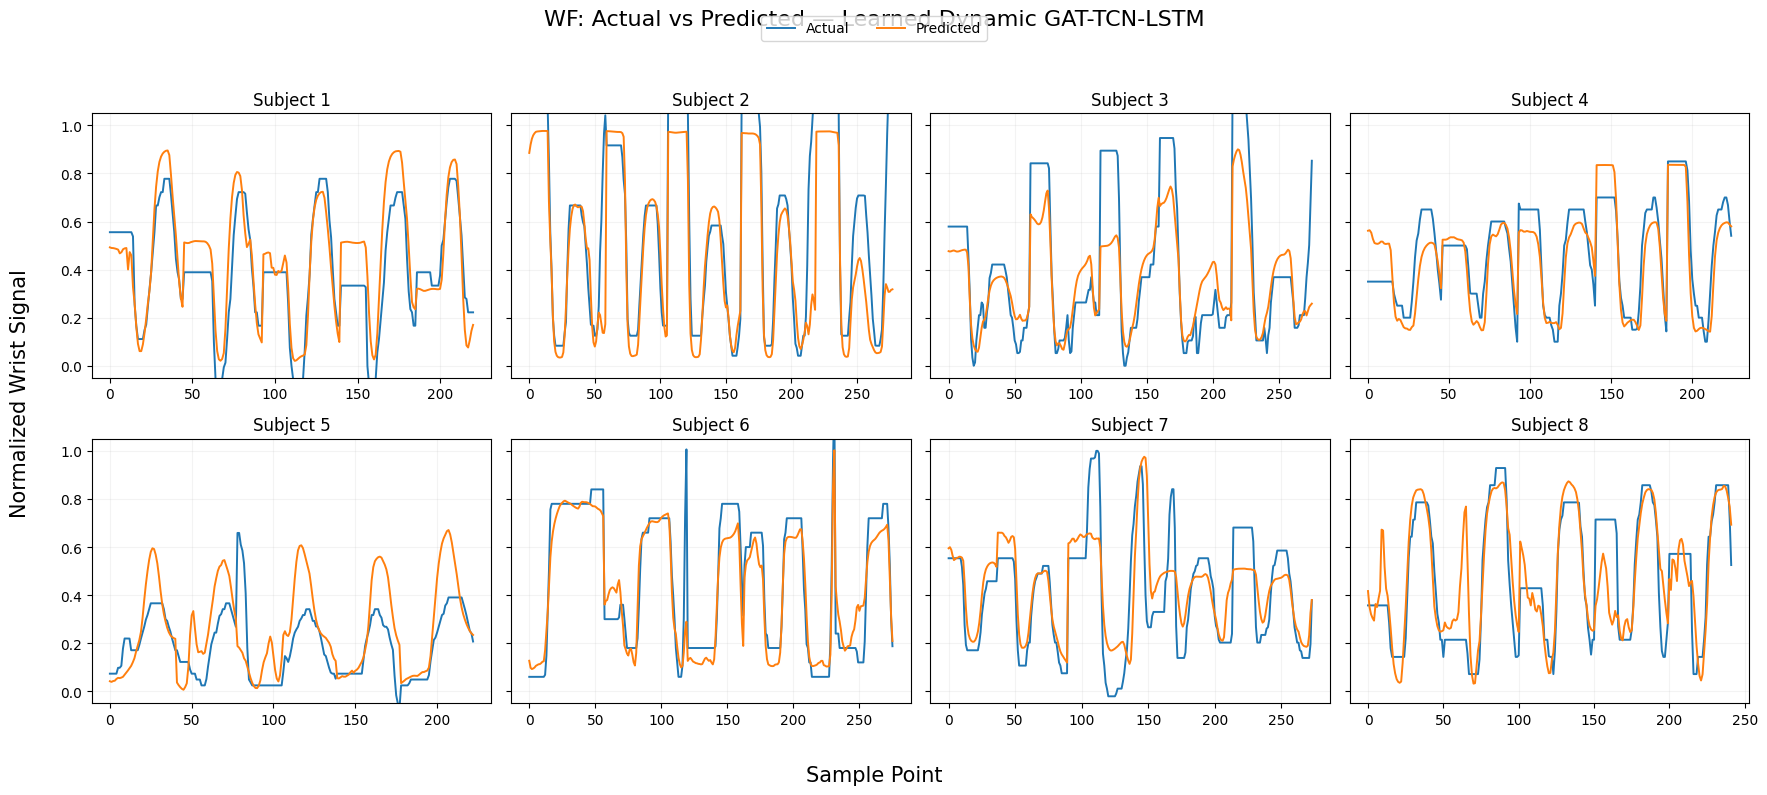

Saved: /kaggle/working/ninapro_db1_learned_dynamic_gat/results/figures/Learned_Dynamic_GAT_WF_eight_subjects.png


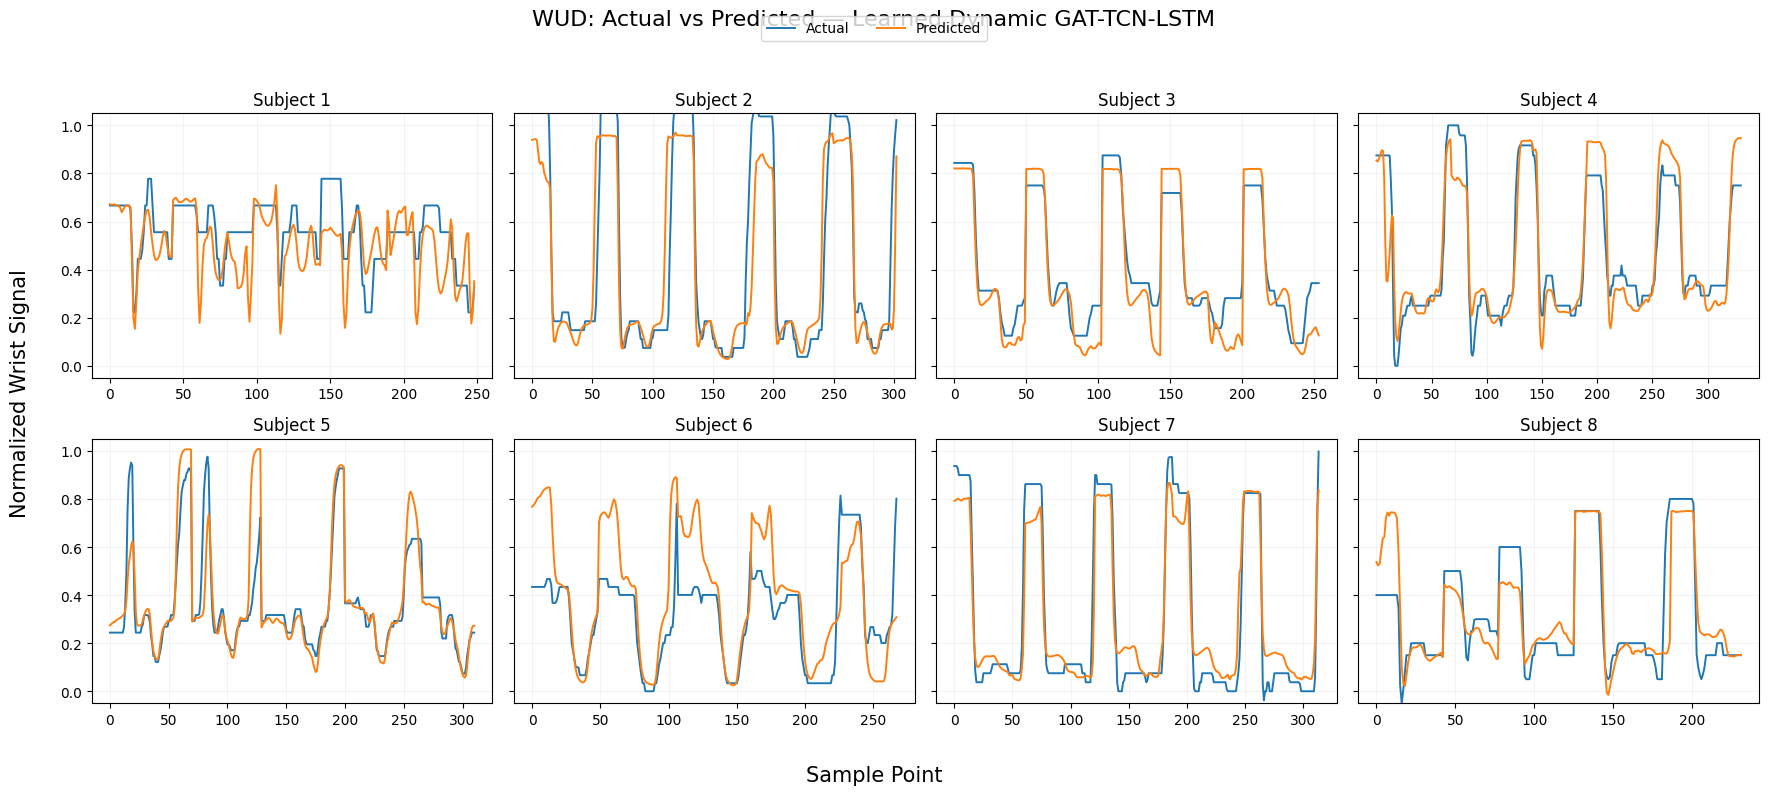

Saved: /kaggle/working/ninapro_db1_learned_dynamic_gat/results/figures/Learned_Dynamic_GAT_WUD_eight_subjects.png


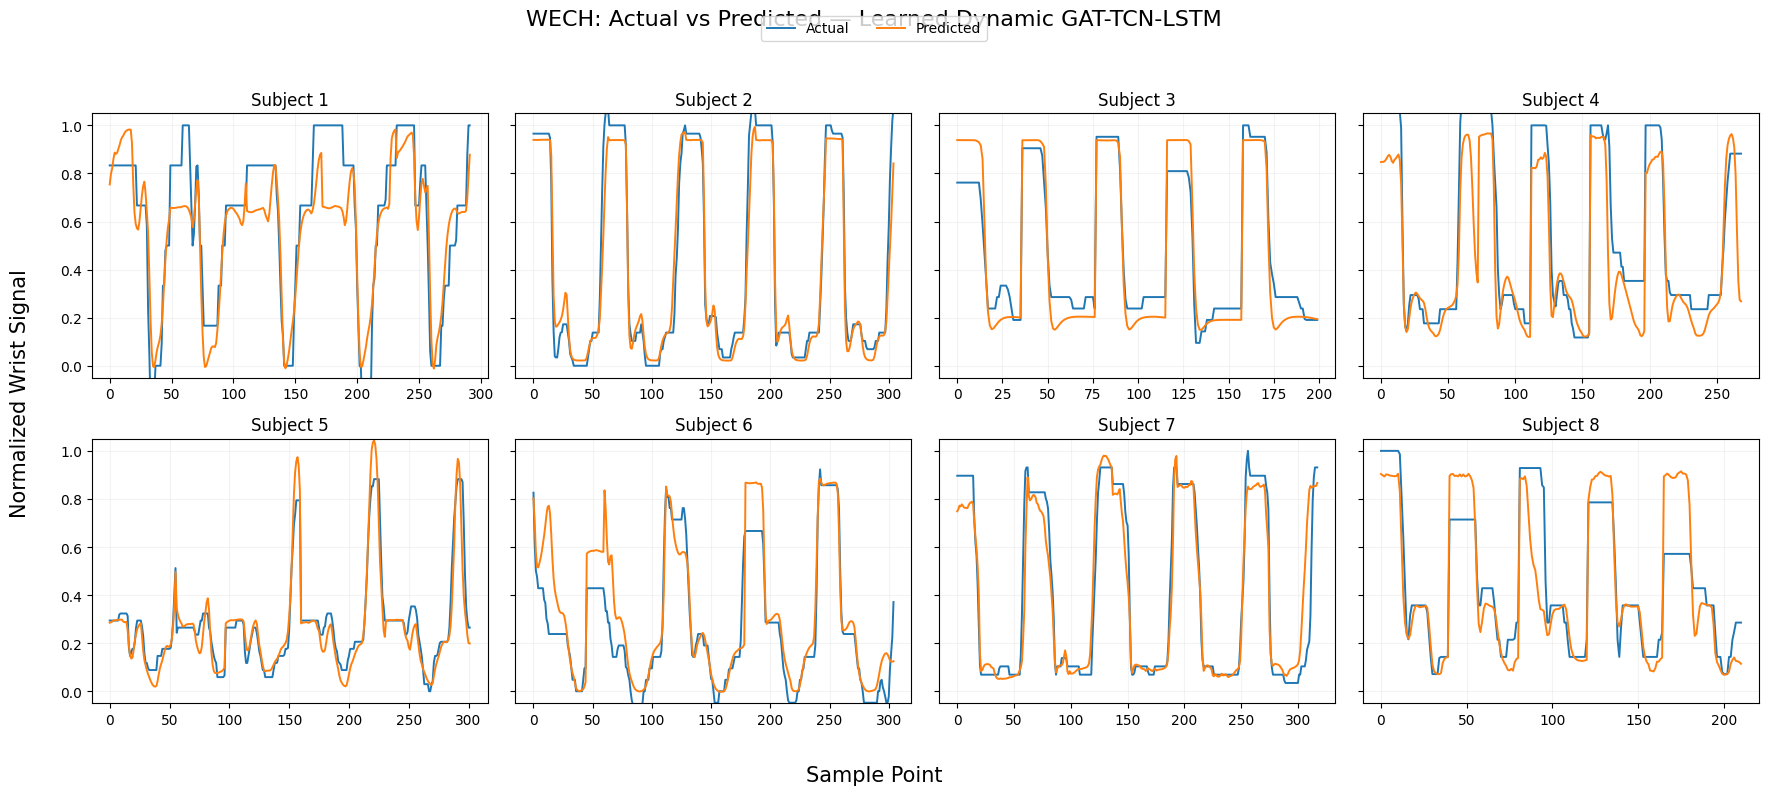

Saved: /kaggle/working/ninapro_db1_learned_dynamic_gat/results/figures/Learned_Dynamic_GAT_WECH_eight_subjects.png


In [47]:
def load_prediction(subject, movement):
    path = prediction_path(
        subject,
        movement,
    )

    if not path.exists():
        raise FileNotFoundError(path)

    with np.load(path) as cache:
        return {
            key: cache[key]
            for key in cache.files
        }


def plot_eight_subject_trajectories(
    movement=17,
    max_points=450,
):
    movement_name = MOVEMENTS[movement]

    figure, axes = plt.subplots(
        2,
        4,
        figsize=(18, 8),
        sharey=True,
    )

    axes = axes.flatten()

    for axis, subject in zip(
        axes,
        SUBJECTS,
    ):
        data = load_prediction(
            subject,
            movement,
        )

        actual = data["y_true"].reshape(-1)
        predicted = data["prediction"].reshape(-1)
        repetitions = data["repetitions"]
        indices = data["target_indices"]

        order = np.lexsort(
            (indices, repetitions)
        )

        actual = actual[order][:max_points]
        predicted = predicted[order][:max_points]

        axis.plot(
            actual,
            label="Actual",
            linewidth=1.4,
        )

        axis.plot(
            predicted,
            label="Predicted",
            linewidth=1.4,
        )

        axis.set_title(
            f"Subject {subject}"
        )

        axis.set_ylim(
            -0.05,
            1.05,
        )

        axis.grid(alpha=0.15)

    figure.supylabel(
        "Normalized Wrist Signal",
        fontsize=15,
    )

    figure.supxlabel(
        "Sample Point",
        fontsize=15,
    )

    figure.suptitle(
        (
            f"{movement_name}: "
            "Actual vs Predicted — "
            "Learned Dynamic GAT-TCN-LSTM"
        ),
        fontsize=16,
    )

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )

    figure.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.98),
    )

    plt.tight_layout(
        rect=(0.02, 0.02, 1, 0.94)
    )

    save_path = (
        FIGURE_DIR
        / (
            f"Learned_Dynamic_GAT_"
            f"{movement_name}_"
            "eight_subjects.png"
        )
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", save_path)


if RUN_PRESET == "full":
    for movement in [13, 16, 17]:
        plot_eight_subject_trajectories(
            movement=movement,
            max_points=450,
        )

## 22. Learned dynamic adjacency heatmap

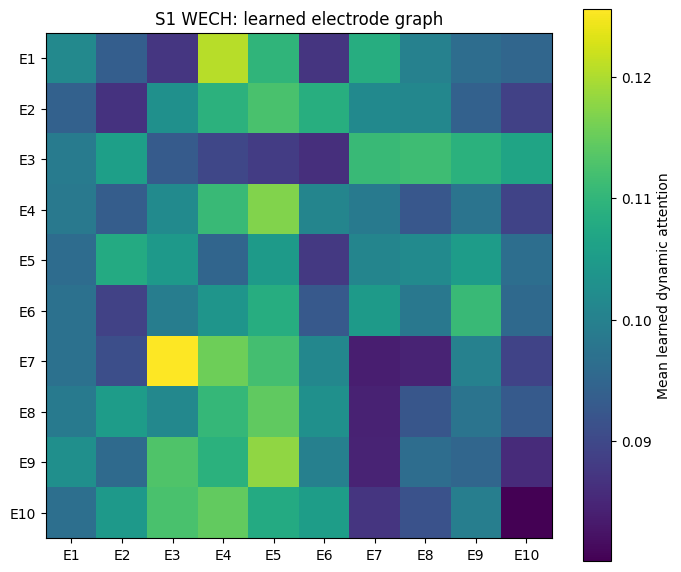

Final fusion scale: 0.009568125009536743


In [48]:
@torch.no_grad()
def inspect_dynamic_graph(
    subject=1,
    movement=17,
    examples=64,
):
    saved = torch.load(
        checkpoint_path(
            subject,
            movement,
        ),
        map_location=DEVICE,
        weights_only=True,
    )

    model = LearnedDynamicGATTCNLSTM().to(
        DEVICE
    )

    model.load_state_dict(
        saved["model_state_dict"]
    )

    model.eval()

    raw = build_all_raw(
        subject,
        movement,
    )

    split = make_scaled_split(
        raw,
        FINAL_TRAIN_REPETITIONS,
        (),
        TEST_REPETITIONS,
    )

    base = torch.from_numpy(
        split["B_test"][:examples]
    ).float().to(DEVICE)

    nodes = torch.from_numpy(
        split["N_test"][:examples]
    ).float().to(DEVICE)

    output = model(
        base,
        nodes,
        return_attention=True,
    )

    attention = (
        output["attention2"]
        .mean(dim=(0, 1, 2))
        .cpu()
        .numpy()
    )

    plt.figure(figsize=(7, 6))

    image = plt.imshow(
        attention,
        aspect="equal",
    )

    plt.colorbar(
        image,
        label="Mean learned dynamic attention",
    )

    labels = [
        f"E{i}"
        for i in range(1, N_EMG + 1)
    ]

    plt.xticks(
        range(N_EMG),
        labels,
    )

    plt.yticks(
        range(N_EMG),
        labels,
    )

    plt.title(
        (
            f"S{subject} {MOVEMENTS[movement]}: "
            "learned electrode graph"
        )
    )

    plt.tight_layout()
    plt.show()

    print(
        "Final fusion scale:",
        float(output["fusion_scale"].cpu()),
    )


if RUN_PRESET == "full":
    inspect_dynamic_graph(
        subject=1,
        movement=17,
    )

## 23. Final comparison with previous baselines

The baseline models are **not retrained here**.

These constants use the previous notebook averages already obtained in the project.

In [49]:
OLD_TCN_RMSE = 0.145161625
OLD_TCN_R2 = 0.609137125

OLD_LSTM_RMSE = 0.13392825
OLD_LSTM_R2 = 0.659874625

OLD_TCNLSTM_RMSE = 0.13193475
OLD_TCNLSTM_R2 = 0.675548375

PREVIOUS_MS_GAT_RMSE = 0.13271508976373683
PREVIOUS_MS_GAT_R2 = 0.6843620464205742

PREVIOUS_AST_GAT_RMSE = 0.1332804740805722
PREVIOUS_AST_GAT_R2 = 0.6745332901676496

comparison = pd.DataFrame(
    {
        "Model": [
            "TCN",
            "LSTM",
            "TCN-LSTM",
            "Cosine Direct-Fusion GAT-TCN-LSTM",
            "AST-GAT-TCN-LSTM",
            "Learned Dynamic GAT-TCN-LSTM",
        ],
        "RMSE": [
            OLD_TCN_RMSE,
            OLD_LSTM_RMSE,
            OLD_TCNLSTM_RMSE,
            PREVIOUS_MS_GAT_RMSE,
            PREVIOUS_AST_GAT_RMSE,
            overall_rmse,
        ],
        "R2": [
            OLD_TCN_R2,
            OLD_LSTM_R2,
            OLD_TCNLSTM_R2,
            PREVIOUS_MS_GAT_R2,
            PREVIOUS_AST_GAT_R2,
            overall_r2,
        ],
    }
)

display(comparison.round(6))

rmse_reduction = (
    100.0
    * (
        OLD_TCNLSTM_RMSE
        - overall_rmse
    )
    / OLD_TCNLSTM_RMSE
)

r2_gain = (
    overall_r2
    - OLD_TCNLSTM_R2
)

print(
    "RMSE reduction vs TCN-LSTM:",
    f"{rmse_reduction:+.3f}%",
)

print(
    "R2 gain vs TCN-LSTM:",
    f"{r2_gain:+.6f}",
)

beat_baseline = (
    overall_rmse < OLD_TCNLSTM_RMSE
    and overall_r2 > OLD_TCNLSTM_R2
)

if beat_baseline:
    print(
        "SUCCESS: Learned Dynamic GAT-TCN-LSTM "
        "beats TCN-LSTM on both RMSE and R2."
    )
else:
    print(
        "NOT YET: the model does not beat "
        "TCN-LSTM on both metrics in this run."
    )

comparison.to_csv(
    RESULT_DIR
    / "final_model_comparison.csv",
    index=False,
)

,Model,RMSE,R2
0,TCN,0.145162,0.609137
1,LSTM,0.133928,0.659875
2,TCN-LSTM,0.131935,0.675548
3,Cosine Direct-Fusion GAT-TCN-LSTM,0.132715,0.684362
4,AST-GAT-TCN-LSTM,0.133280,0.674533
5,Learned Dynamic GAT-TCN-LSTM,0.131824,0.685426


RMSE reduction vs TCN-LSTM: +0.084%
R2 gain vs TCN-LSTM: +0.009878
SUCCESS: Learned Dynamic GAT-TCN-LSTM beats TCN-LSTM on both RMSE and R2.


## 24. Main outputs

The most important files are:

- `learned_dynamic_gat_tcn_lstm_all_results.csv`
- `subject_average.csv`
- `movement_average.csv`
- `validation_summary.csv`
- `final_model_comparison.csv`
- one prediction `.npz` for every subject × movement
- validation history for every subject × movement
- final checkpoints
- actual-vs-predicted figures
- learned adjacency heatmap

### Success condition

Use the proposed model as the final winner only if:

- overall RMSE `< 0.13193475`
- overall \(R^2 > 0.675548375\)

The notebook does not fabricate or prefill the new model's result.